In [83]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
from sklearn.cluster import DBSCAN
from sklearn.decomposition import PCA
from sklearn.datasets import make_blobs
from sklearn.neighbors import NearestNeighbors

In [84]:
# Load the dataset
df = pd.read_csv("C:/Users/ragu/capstone_pj/dataset/customer_segmentation.csv")

In [85]:
df.head()

,Customer_ID,Age,Gender,Location,Occupation,Income_Level,Insurance_Products_Owned,Coverage_Amount,Premium_Amount,Policy_Type
0,84966,23,Female,Mizoram,Entrepreneur,70541,policy2,366603,2749,Group
1,95568,26,Male,Goa,Manager,54168,policy1,780236,1966,Group
2,10544,29,Female,Rajasthan,Entrepreneur,73899,policy3,773926,4413,Group
3,77033,20,Male,Sikkim,Entrepreneur,63381,policy2,787815,4342,Family
4,88160,25,Female,West Bengal,Manager,38794,policy4,366506,1276,Family


In [86]:
# change the columns names to lowercase
df.columns = df.columns.str.lower()

In [87]:
# find the null values in the dataset
df.isnull().sum()

customer_id                 0
age                         0
gender                      0
location                    0
occupation                  0
income_level                0
insurance_products_owned    0
coverage_amount             0
premium_amount              0
policy_type                 0
dtype: int64

In [88]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53503 entries, 0 to 53502
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               53503 non-null  int64 
 1   age                       53503 non-null  int64 
 2   gender                    53503 non-null  object
 3   location                  53503 non-null  object
 4   occupation                53503 non-null  object
 5   income_level              53503 non-null  int64 
 6   insurance_products_owned  53503 non-null  object
 7   coverage_amount           53503 non-null  int64 
 8   premium_amount            53503 non-null  int64 
 9   policy_type               53503 non-null  object
dtypes: int64(5), object(5)
memory usage: 4.1+ MB


In [89]:
df.describe(include="all")

,customer_id,age,gender,location,occupation,income_level,insurance_products_owned,coverage_amount,premium_amount,policy_type
count,53503.000000,53503.000000,53503,53503,53503,53503.000000,53503,53503.000000,53503.000000,53503
unique,NaN,NaN,2,35,9,NaN,5,NaN,NaN,4
top,NaN,NaN,Male,Lakshadweep,Salesperson,NaN,policy1,NaN,NaN,Group
freq,NaN,NaN,27499,2140,7919,NaN,13365,NaN,NaN,18255
mean,52265.204998,44.140945,NaN,NaN,NaN,82768.324318,NaN,492580.789638,3023.702447,NaN
std,28165.000067,15.079486,NaN,NaN,NaN,36651.075670,NaN,268405.505571,1285.834295,NaN
min,1.000000,18.000000,NaN,NaN,NaN,20001.000000,NaN,50001.000000,500.000000,NaN
25%,28950.500000,32.000000,NaN,NaN,NaN,51568.500000,NaN,249613.500000,1817.000000,NaN
50%,55858.000000,43.000000,NaN,NaN,NaN,80719.000000,NaN,477261.000000,3194.000000,NaN
75%,76096.000000,57.000000,NaN,NaN,NaN,115973.500000,NaN,739124.000000,4311.500000,NaN


In [90]:
#Checking for duplicates in the dataset
df.duplicated().sum()

0

In [91]:
# Mapping categorical variables to numerical values
policy_types = {
    "Individual": 0,
    "Family": 1,
    "Group": 2,
    "Business": 3
}

df["policy_upgrades"] = df["policy_type"].map(policy_types)

In [92]:
# extract number_of_policies
df["number_of_policies"] = df["insurance_products_owned"].str.extract(r"policy(\d)").astype(int)

In [93]:
df.head()

,customer_id,age,gender,location,occupation,income_level,insurance_products_owned,coverage_amount,premium_amount,policy_type,policy_upgrades,number_of_policies
0,84966,23,Female,Mizoram,Entrepreneur,70541,policy2,366603,2749,Group,2,2
1,95568,26,Male,Goa,Manager,54168,policy1,780236,1966,Group,2,1
2,10544,29,Female,Rajasthan,Entrepreneur,73899,policy3,773926,4413,Group,2,3
3,77033,20,Male,Sikkim,Entrepreneur,63381,policy2,787815,4342,Family,1,2
4,88160,25,Female,West Bengal,Manager,38794,policy4,366506,1276,Family,1,4


In [94]:
# Explorotory Data Analysis
df.head()

,customer_id,age,gender,location,occupation,income_level,insurance_products_owned,coverage_amount,premium_amount,policy_type,policy_upgrades,number_of_policies
0,84966,23,Female,Mizoram,Entrepreneur,70541,policy2,366603,2749,Group,2,2
1,95568,26,Male,Goa,Manager,54168,policy1,780236,1966,Group,2,1
2,10544,29,Female,Rajasthan,Entrepreneur,73899,policy3,773926,4413,Group,2,3
3,77033,20,Male,Sikkim,Entrepreneur,63381,policy2,787815,4342,Family,1,2
4,88160,25,Female,West Bengal,Manager,38794,policy4,366506,1276,Family,1,4


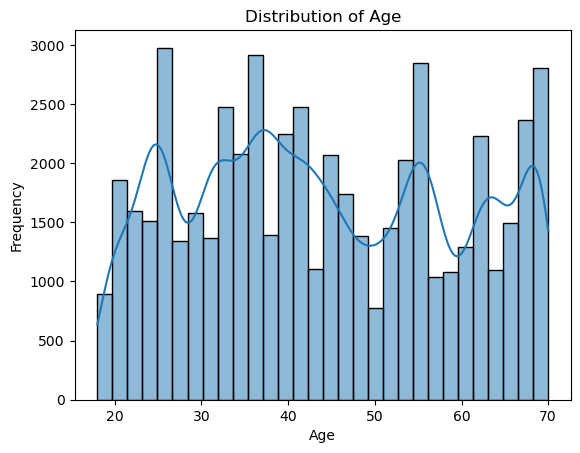

In [95]:
#Uinivariate Analysis

sns.histplot(df["age"], kde=True, bins=30)
plt.title("Distribution of Age")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

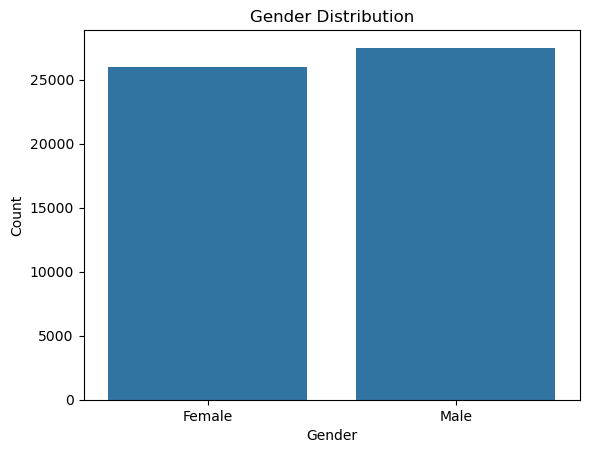

In [96]:
sns.countplot(x="gender", data=df)
plt.title("Gender Distribution")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.show()

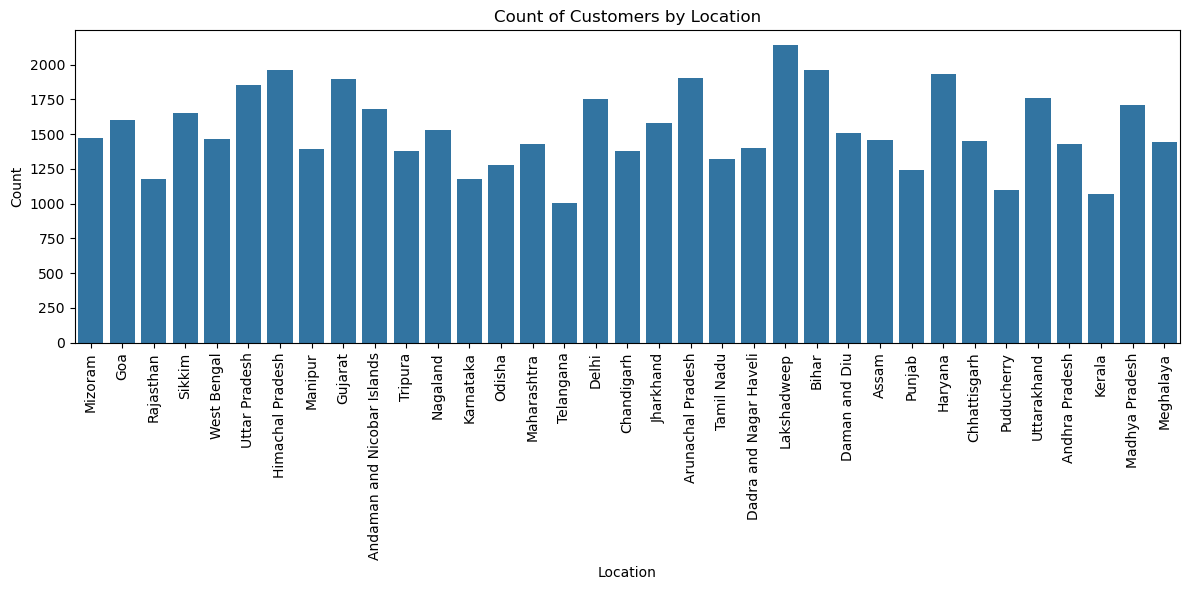

In [97]:
plt.figure(figsize=(12, 6))
sns.countplot(x="location", data=df)
plt.title("Count of Customers by Location")
plt.xlabel("Location")
plt.ylabel("Count")
plt.xticks(rotation=90)  
plt.tight_layout()
plt.show()

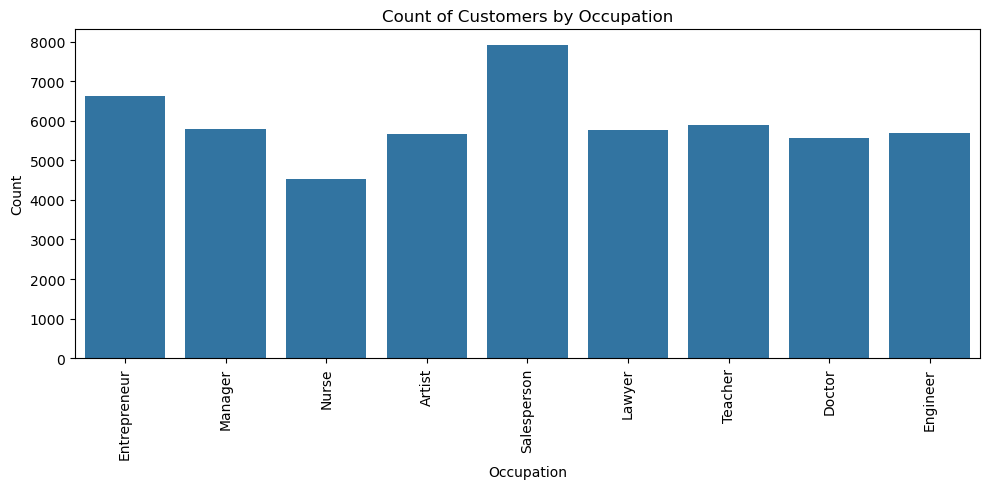

In [98]:
plt.figure(figsize=(10, 5))
sns.countplot(x="occupation", data=df)
plt.title("Count of Customers by Occupation")
plt.xlabel("Occupation")
plt.ylabel("Count")
plt.xticks(rotation=90) 
plt.tight_layout()
plt.show() 

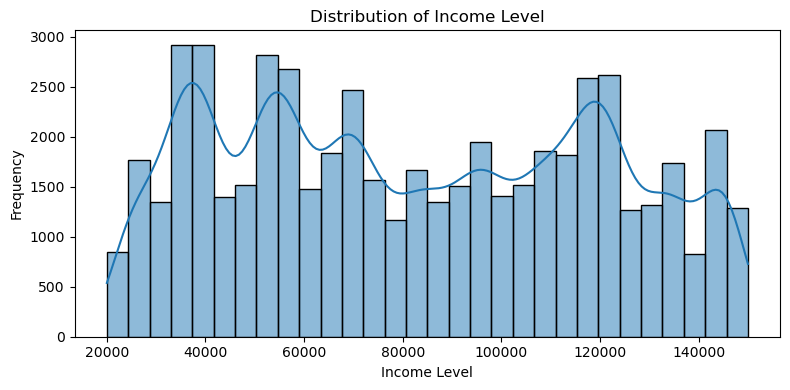

In [99]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
sns.histplot(df["income_level"], bins=30, kde=True)
plt.title("Distribution of Income Level")
plt.xlabel("Income Level")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

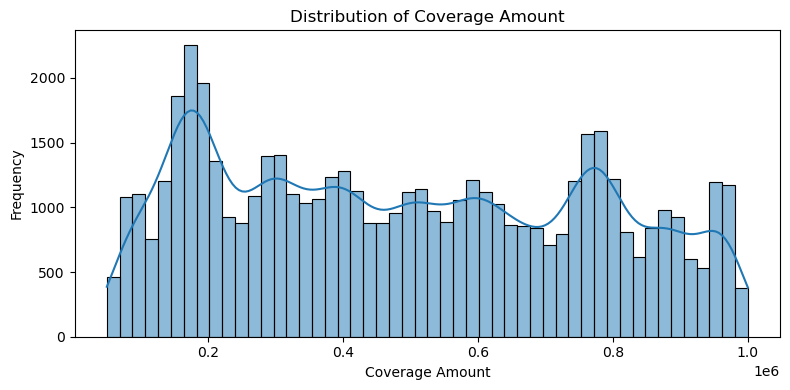

In [100]:
plt.figure(figsize=(8, 4))
sns.histplot(df["coverage_amount"], bins=50, kde=True)
plt.title("Distribution of Coverage Amount")
plt.xlabel("Coverage Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

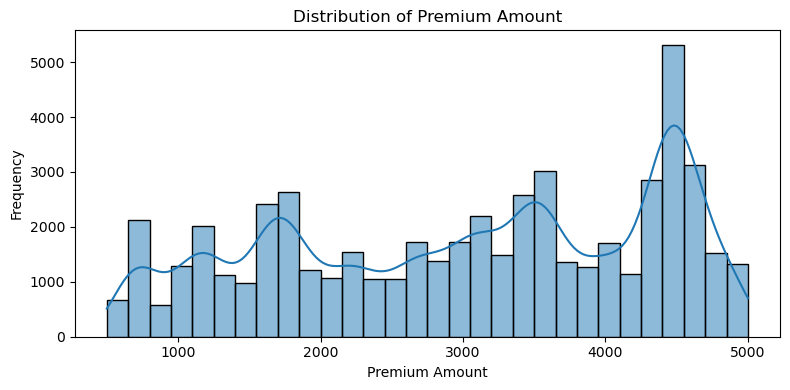

In [101]:
plt.figure(figsize=(8, 4))
sns.histplot(df["premium_amount"], bins=30, kde=True)
plt.title("Distribution of Premium Amount")
plt.xlabel("Premium Amount")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

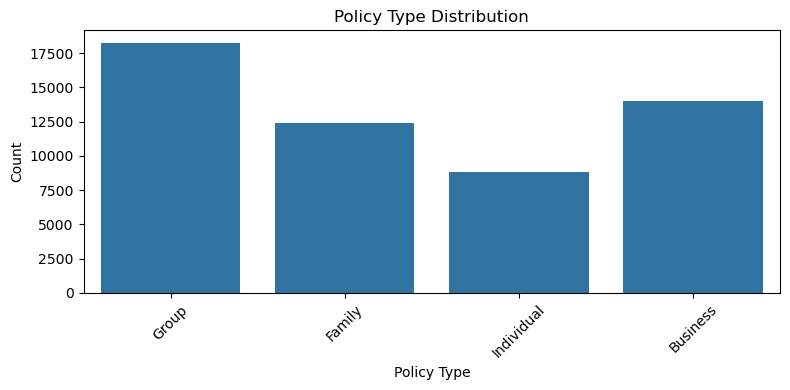

In [102]:
plt.figure(figsize=(8, 4))
sns.countplot(x="policy_type", data=df)  
plt.title("Policy Type Distribution")
plt.xlabel("Policy Type")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

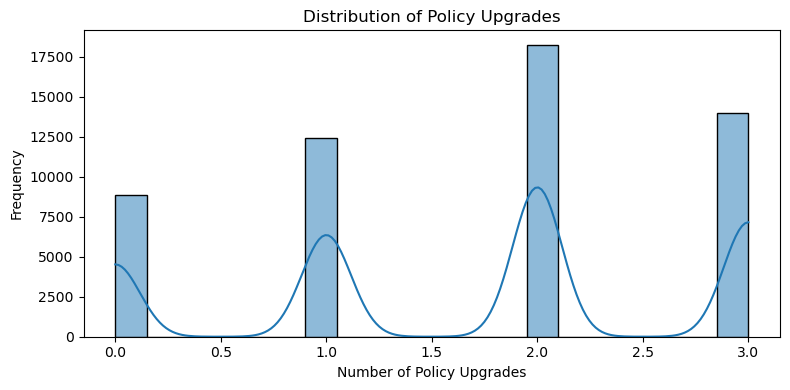

In [103]:
plt.figure(figsize=(8, 4))
sns.histplot(df["policy_upgrades"], bins=20, kde=True)
plt.title("Distribution of Policy Upgrades")
plt.xlabel("Number of Policy Upgrades")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

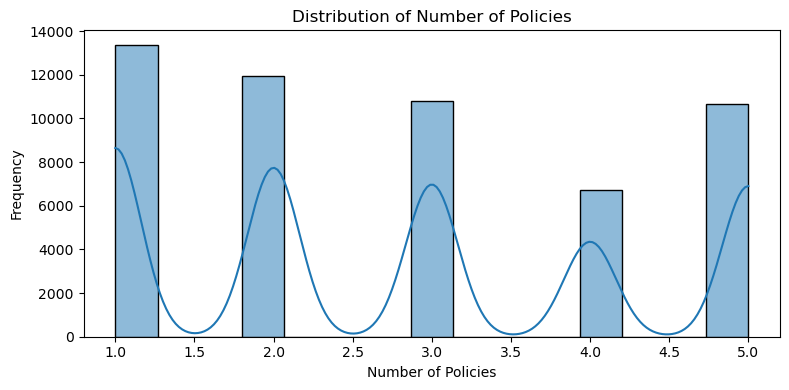

In [104]:
plt.figure(figsize=(8, 4))
sns.histplot(df["number_of_policies"], bins=15, kde=True)
plt.title("Distribution of Number of Policies")
plt.xlabel("Number of Policies")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

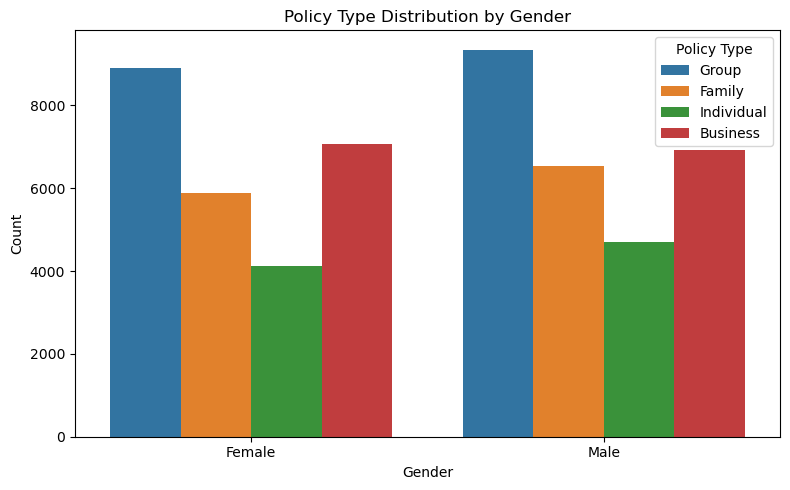

In [105]:
# Bivariate Analysis
plt.figure(figsize=(8, 5))
sns.countplot(x="gender", hue="policy_type", data=df)
plt.title("Policy Type Distribution by Gender")
plt.xlabel("Gender")
plt.ylabel("Count")
plt.legend(title="Policy Type")
plt.tight_layout()
plt.show()

<Axes: xlabel='count', ylabel='location'>

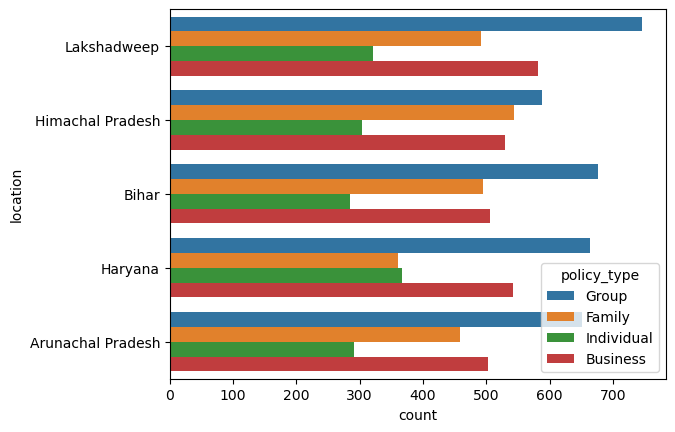

In [106]:
sns.countplot(data=df, y="location", hue="policy_type", order=df["location"].value_counts().index[:5])

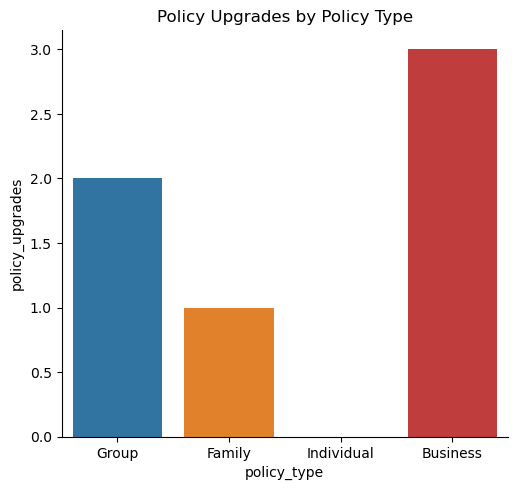

In [107]:
sns.catplot(data=df, x="policy_type", y="policy_upgrades", hue="policy_type", kind="bar", aspect=1.1, height=4.8)
plt.title("Policy Upgrades by Policy Type")
plt.show()

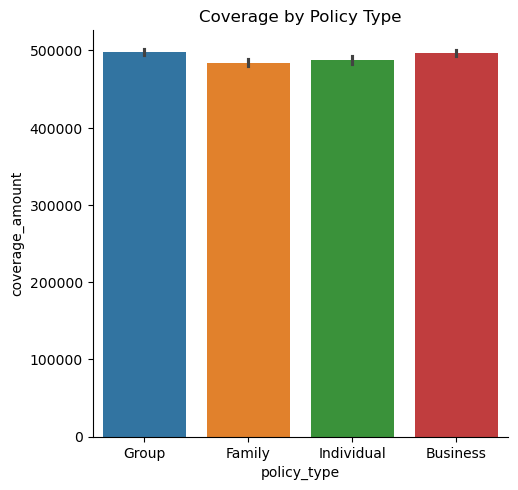

In [108]:
sns.catplot(data=df, y="coverage_amount", x="policy_type", hue="policy_type", kind="bar", aspect=1.1, height=4.8)
plt.title("Coverage by Policy Type")
plt.show()

In [109]:
df.columns

Index(['customer_id', 'age', 'gender', 'location', 'occupation',
       'income_level', 'insurance_products_owned', 'coverage_amount',
       'premium_amount', 'policy_type', 'policy_upgrades',
       'number_of_policies'],
      dtype='object')

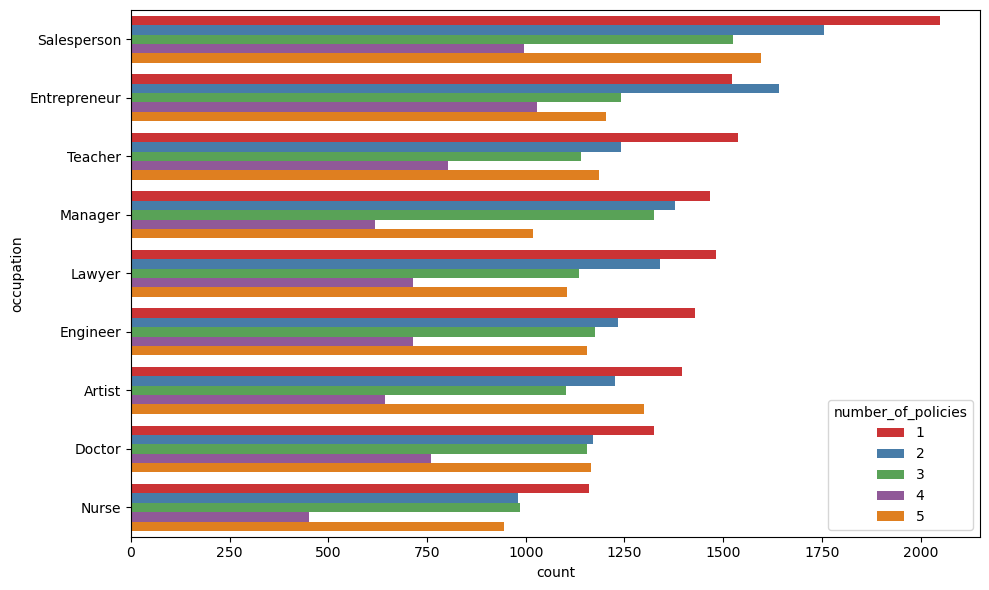

In [110]:
plt.figure(figsize=(10, 6))
sns.countplot(data=df, y="occupation", hue="number_of_policies",
              order=df["occupation"].value_counts().index, palette="Set1")
plt.tight_layout()
plt.show()

In [111]:
#Corelation Matrix
corr_matrix = df.select_dtypes(include="number").corr()
print("\nCorrelation Matrix:\n")
print(corr_matrix.round(3))


Correlation Matrix:

                    customer_id    age  income_level  coverage_amount  \
customer_id               1.000 -0.014         0.011            0.004   
age                      -0.014  1.000        -0.003            0.007   
income_level              0.011 -0.003         1.000           -0.018   
coverage_amount           0.004  0.007        -0.018            1.000   
premium_amount           -0.007  0.004         0.002           -0.002   
policy_upgrades          -0.007  0.000         0.000            0.017   
number_of_policies       -0.019  0.013         0.015            0.006   

                    premium_amount  policy_upgrades  number_of_policies  
customer_id                 -0.007           -0.007              -0.019  
age                          0.004            0.000               0.013  
income_level                 0.002            0.000               0.015  
coverage_amount             -0.002            0.017               0.006  
premium_amount         

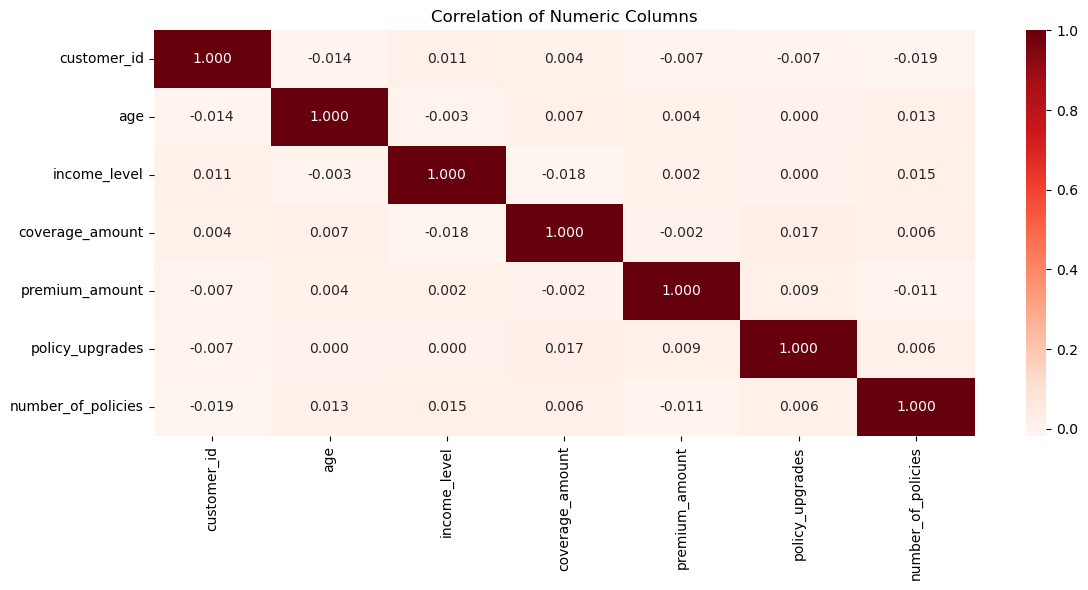

In [112]:
#Corelation Matrix Visualization
plt.figure(figsize=(12, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap="Reds")
plt.title("Correlation of Numeric Columns")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

In [ ]:
# Model Building

In [113]:
# one hot Encoding
one_hot_encode = df[["gender", "occupation"]]
one_hot_encode = pd.get_dummies(one_hot_encode, columns=["gender", "occupation"], drop_first=True).astype(int)

In [114]:
# Label Encoding
df["location"] = LabelEncoder().fit_transform(df["location"])

In [115]:
#remove and add encoded columns
feature = df.drop(columns=["customer_id", "gender", "occupation", "insurance_products_owned", "policy_type"], inplace=True)

feature = pd.concat([df, one_hot_encode],axis=1)

In [116]:
feature.head()

,age,location,income_level,coverage_amount,premium_amount,policy_upgrades,number_of_policies,gender_Male,occupation_Doctor,occupation_Engineer,occupation_Entrepreneur,occupation_Lawyer,occupation_Manager,occupation_Nurse,occupation_Salesperson,occupation_Teacher
0,23,22,70541,366603,2749,2,2,0,0,0,1,0,0,0,0,0
1,26,10,54168,780236,1966,2,1,1,0,0,0,0,1,0,0,0
2,29,27,73899,773926,4413,2,3,0,0,0,1,0,0,0,0,0
3,20,28,63381,787815,4342,1,2,1,0,0,1,0,0,0,0,0
4,25,34,38794,366506,1276,1,4,0,0,0,0,0,1,0,0,0


In [117]:
# feature selection

x = feature

In [118]:
# feature scaling
scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

In [119]:
model = KMeans(n_clusters=3, random_state=0)

In [120]:
model.fit(x_scaled)

KMeans(n_clusters=3, random_state=0)

In [121]:
y_pred = model.predict(x_scaled)

In [122]:
silhouette_score(x_scaled, y_pred)

0.12380538849129252

In [123]:
df["cluster"] = model.labels_

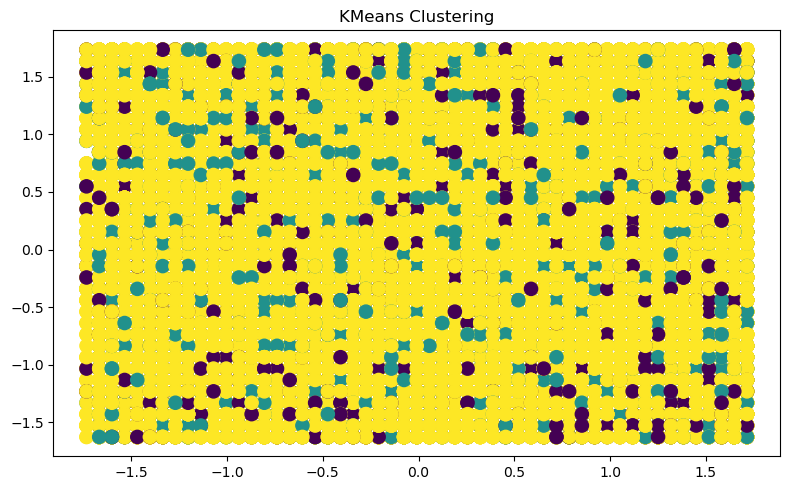

In [124]:
plt.figure(figsize=(8, 5))
plt.scatter(x_scaled[:, 0], x_scaled[:, 1], c=df["cluster"], s=90)
plt.title("KMeans Clustering")
plt.tight_layout()
plt.show()

In [125]:
# Apply DBSCAN
dbscan = DBSCAN(eps=0.5, min_samples=4)
labels = dbscan.fit_predict(x_scaled)

In [126]:
# Number of unique labels (excluding noise)
unique_labels = set(labels)
n_clusters = len(unique_labels - {-1})

if n_clusters >= 2:
    mask = labels != -1
    score = silhouette_score(x_scaled[mask], labels[mask])
    print(f"Silhouette Score (excluding noise): {score:.4f}")
else:
    print("Silhouette Score not applicable — only one cluster or all points are noise.")

Silhouette Score (excluding noise): 0.8475


In [127]:
#PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x_scaled)

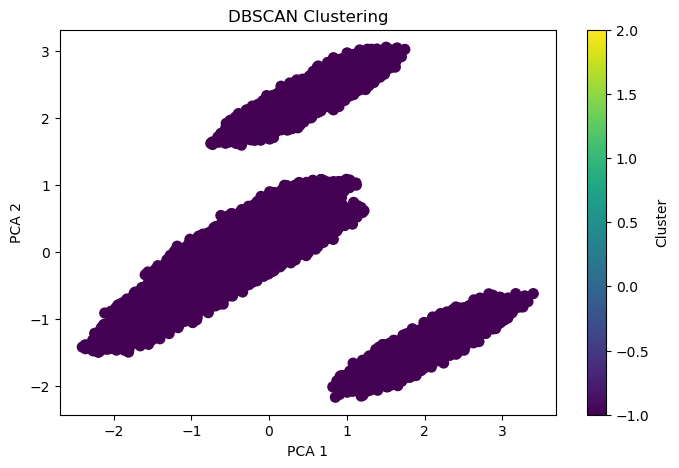

In [128]:
# Plotting the PCA results
plt.figure(figsize=(8, 5))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50)
plt.title("DBSCAN Clustering")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(label='Cluster')
plt.show()

In [129]:
df1 = pd.DataFrame(x_scaled, columns=[f'feature_{i}' for i in range(x_scaled.shape[1])])
df1['Cluster'] = labels

# Assign names to each cluster (example)
cluster_names = {
    0: "Premium Loyalists",
    1: "Low-Risk Seniors",
    2: "Occasional Buyers",
    -1: "Noise"
}
# Map the cluster names to the DataFrame
df1['Cluster_Name'] = df1['Cluster'].map(cluster_names)

In [130]:
import joblib

# Save the model
joblib.dump(dbscan, 'dbscan_model_cs.pkl')

# Also save the scaler if needed
joblib.dump(scaler, 'scaler_cs.pkl')

# If you used PCA for visual plots or dimensionality reduction
joblib.dump(pca, 'pca_cs.pkl')

['pca_cs.pkl']

In [131]:
# Load model and scaler
dbscan = joblib.load('C:/Users/ragu/capstone_pj/vs/dbscan_model_cs.pkl')
scaler = joblib.load('C:/Users/ragu/capstone_pj/vs/scaler_cs.pkl')
pca = joblib.load('C:/Users/ragu/capstone_pj/vs/pca_cs.pkl')

In [133]:
cluster_names = {
    0: "Premium Loyalists",
    1: "Low-Risk Seniors",
    2: "Occasional Buyers",
    -1: "Noise"
}

predicted_labels = [cluster_names.get(label, "Unknown") for label in labels]

In [134]:
df1.tail()

,feature_0,feature_1,feature_2,feature_3,feature_4,feature_5,feature_6,feature_7,feature_8,feature_9,feature_10,feature_11,feature_12,feature_13,feature_14,feature_15,Cluster,Cluster_Name
53498,-0.606190,-1.625046,1.039043,0.349550,1.073475,-0.677587,-1.241050,-1.028344,-0.340989,-0.345446,-0.376287,-0.347848,-0.348792,-0.303808,2.399225,-0.352255,-1,Noise
53499,1.118023,-0.341007,1.078851,0.540800,-1.352211,0.292028,0.825916,0.972437,-0.340989,-0.345446,2.657544,-0.347848,-0.348792,-0.303808,-0.416801,-0.352255,-1,Noise
53500,-1.269349,-1.328729,-0.914315,0.515926,1.075808,-1.647202,-1.241050,0.972437,-0.340989,-0.345446,-0.376287,-0.347848,-0.348792,-0.303808,-0.416801,2.838854,-1,Noise
53501,-0.141979,-1.526274,-0.449304,0.885997,1.134136,1.261643,-1.241050,0.972437,-0.340989,-0.345446,-0.376287,-0.347848,-0.348792,-0.303808,-0.416801,-0.352255,-1,Noise
53502,-1.600928,-0.834868,1.469648,0.933973,1.147357,0.292028,-1.241050,0.972437,-0.340989,-0.345446,-0.376287,-0.347848,-0.348792,-0.303808,2.399225,-0.352255,-1,Noise


In [142]:
# Example single test input (same columns as your training data)
new_input = pd.DataFrame([{
    "age": 25,
    "location": 2,
    "income_level": 57187,
    "coverage_amount": 511817,
    "premium_amount": 1154,
    "policy_upgrades": 2,
    "number_of_policies": 4,
    "gender_Male": 1,
    "occupation_Doctor": 1,
    "occupation_Engineer": 0,
    "occupation_Entrepreneur": 0,
    "occupation_Lawyer": 0,
    "occupation_Manager": 0,
    "occupation_Nurse": 0,
    "occupation_Salesperson": 0,
    "occupation_Teacher": 0
}])

# Preprocess input
X_new = scaler.transform(new_input)

# Predict cluster
label = dbscan.fit_predict(X_new)[0]  # Get first (and only) prediction

# Get cluster name
cluster_name = cluster_names.get(label, "Unknown")

# Output result
print(f"This input belongs to the cluster: {cluster_name}")

This input belongs to the cluster: Noise


In [145]:
df1["Cluster_Name"].value_counts()

Cluster_Name
Noise                53491
Premium Loyalists        4
Low-Risk Seniors         4
Occasional Buyers        4
Name: count, dtype: int64